In [1]:
import xarray as xr
import ml_confs
import matplotlib.pyplot as plt
# from ipywidgets import widgets, Layout
# from IPython.display import display, clear_output
from pathlib import Path
import matplotlib.gridspec as gridspec
import numpy as np
import sys
from scipy.signal import savgol_filter

# Configure paths
current_dir = Path.cwd()
project_root = current_dir
sys.path.insert(0, str(project_root))

# Import preprocessing function AFTER path configuration
from spectraformer.input_pipeline import preprocess_dataset
from unmixing import load_model, prediction_fn

maindir = project_root.resolve()
datadir = maindir / "data"
parsed_datadir = datadir / "parsed_data"

configsdir = maindir / "configs"
# configsdir.mkdir(parents=True, exist_ok=True)

ckptdir = maindir / "saved_models" / "checkpoints"

def get_config_path(configsdir, model_number):
    # Find the first config file that matches the pattern
    matches = list(configsdir.glob(f"configs_{model_number}*.yaml"))
    if not matches:
        raise FileNotFoundError(f"No config file found for model number {model_number}")
    return matches[0]

JAX devices:  [CudaDevice(id=0)]


In [23]:
model1 = "min62"

model1_config_file_path = get_config_path(configsdir, model1)
configs1 = ml_confs.from_file(model1_config_file_path)


model2 = "min67"

model2_config_file_path = get_config_path(configsdir, model2)
configs2 = ml_confs.from_file(model2_config_file_path)

dummy_dataset = preprocess_dataset(
    xr.load_dataarray(parsed_datadir / "SiC-high-f/main/main_19x10x3_DepthMapHR100x5p1s1acc.nc"),
    option='whitaker_hayes_with_outliers')
dummy_dataset = dummy_dataset.isel(spectra=0)
dummy_dataset = dummy_dataset.expand_dims("spectra")
dummy_dataset

state1 = load_model(configs1, dataset=dummy_dataset, is_latest=True, desired_step=0, ckptdir=ckptdir)
state2 = load_model(configs2, dataset=dummy_dataset, is_latest=True, desired_step=0, ckptdir=ckptdir)

predictions1 = prediction_fn(configs1, dummy_dataset, state1)
predictions2 = prediction_fn(configs2, dummy_dataset, state2)

Checkpoint restored from step 91650.


Checkpoint restored from step 39245.


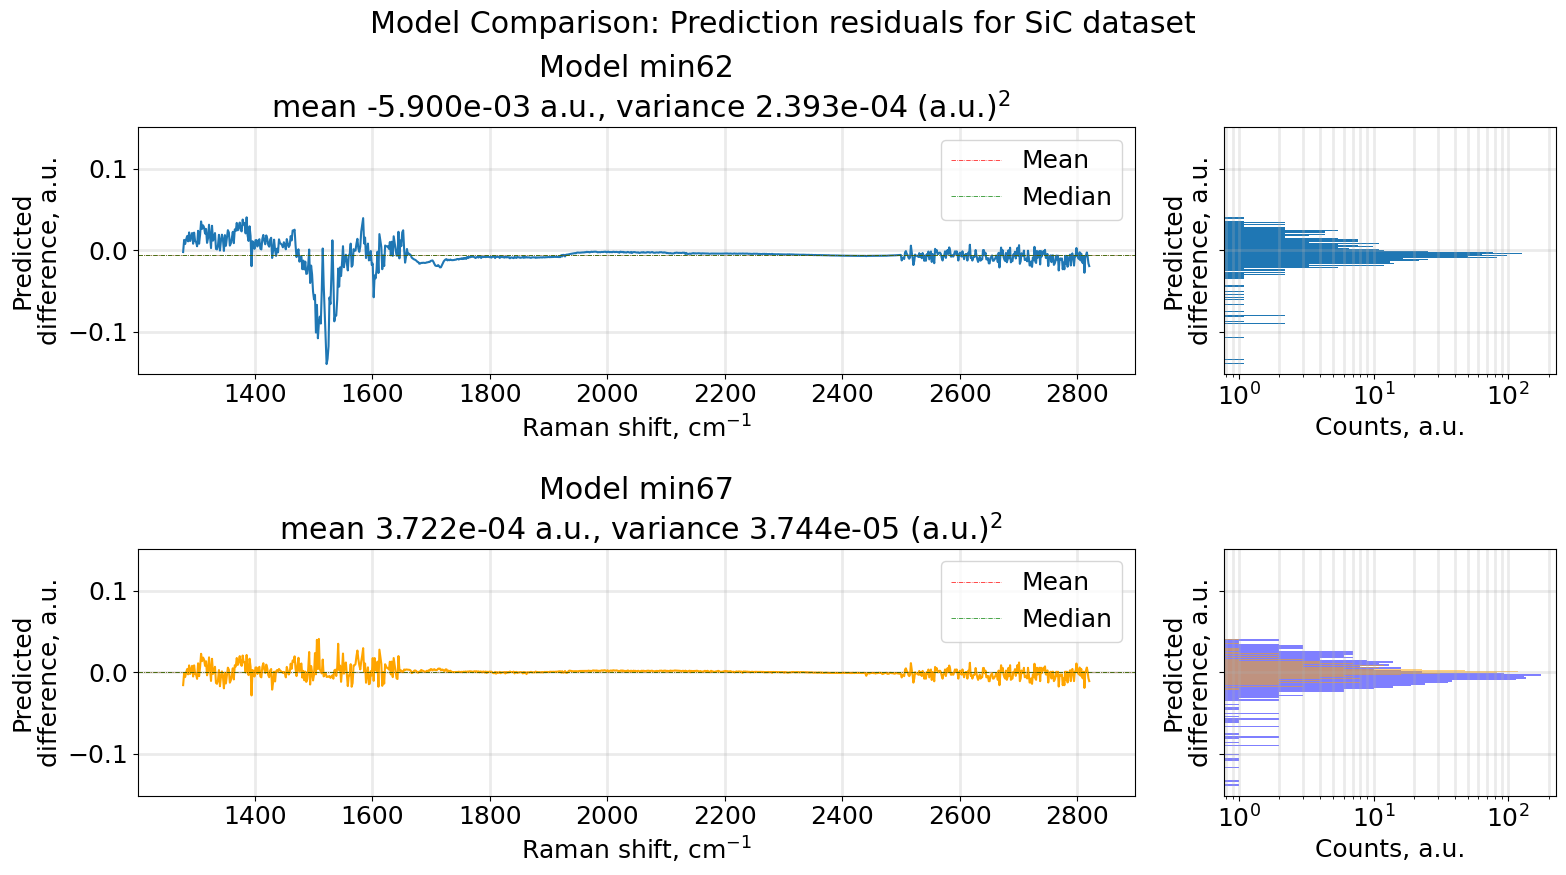

In [57]:
from matplotlib import rcParams
rcParams['font.size'] = 18

fig = plt.figure(figsize=(16, 9))
fig.suptitle("Model Comparison: Prediction residuals for SiC dataset")
axes = fig.subplots(2, 2, sharey=True, gridspec_kw={'width_ratios': [3, 1]})

for ax in axes.flatten():
    ax.grid(visible=True, which='both', axis='both', linestyle='-', linewidth=2, alpha=0.25)
    ax.set_ylabel("Predicted\ndifference, a.u.")

axes[0, 0].plot(dummy_dataset['wave_number'].values, predictions1[0]['predicted_difference'])
axes[0, 0].set_ylim(-0.151, 0.151)
axes[0, 0].set_title(f"Model {model1}\n mean {predictions1[0]['predicted_difference'].mean():.3e} a.u., variance {predictions1[0]['predicted_difference'].var():.3e} (a.u.)$^2$")
axes[0, 0].axhline(predictions1[0]['predicted_difference'].mean(), color='red', linestyle='-.', linewidth=0.5, label='Mean')
axes[0, 0].axhline(np.median(predictions1[0]['predicted_difference']), color='green', linestyle='-.', linewidth=0.5, label='Median')
axes[0, 0].legend()
axes[0, 0].set_xlabel("Raman shift, cm$^{-1}$")

axes[0, 1].hist(predictions1[0]['predicted_difference'], orientation='horizontal', bins=200, density=True)
axes[0, 1].set_xlabel("Counts, a.u.")
# axes[0, 1].set_xlim(0, 200)
axes[0, 1].set_xscale('log')

axes[1, 0].plot(dummy_dataset['wave_number'].values, predictions2[0]['predicted_difference'], color='orange')
axes[1, 0].axhline(predictions2[0]['predicted_difference'].mean(), color='red', linestyle='-.', linewidth=0.5, label='Mean')
axes[1, 0].axhline(np.median(predictions2[0]['predicted_difference']), color='green', linestyle='-.', linewidth=0.5, label='Median')
axes[1, 0].legend()
axes[1, 0].set_title(f"Model {model2}\n mean {predictions2[0]['predicted_difference'].mean():.3e} a.u., variance {predictions2[0]['predicted_difference'].var():.3e} (a.u.)$^2$")
axes[1, 0].set_xlabel("Raman shift, cm$^{-1}$")
axes[1, 0].sharex(axes[0, 0])

# axes[1, 1].hist( (predictions1[0]['predicted_difference'], predictions2[0]['predicted_difference']), orientation='horizontal', bins=100
#                 # , color=('blue','orange')
#                 )
axes[1, 1].hist(predictions1[0]['predicted_difference'], orientation='horizontal', bins=100, color='blue', alpha=0.5)
axes[1, 1].hist(predictions2[0]['predicted_difference'], orientation='horizontal', bins=100, color='orange', alpha=0.5)
axes[1, 1].set_xlabel("Counts, a.u.")
axes[1, 1].sharex(axes[0, 1])
axes[1, 1].set_xscale('log')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()